In [23]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, mean_absolute_percentage_error)
import warnings
warnings.filterwarnings("ignore")


In [24]:
# DATA LOADING
df = pd.read_csv("monthly_milk_production.csv", index_col="Date", parse_dates=True)


In [25]:
# Display the full DataFrame — 168 monthly observations from Jan 1962 to Dec 1975
df

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


In [26]:
# Check for missing values — neural networks cannot handle NaN inputs
# The milk production dataset has no missing values but we always verify
df.isnull().sum()

Production    0
dtype: int64

In [27]:
# Dataset information — column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [28]:
# Column names
df.columns

Index(['Production'], dtype='object')

In [29]:
# Value counts — shows how many times each production value appears
df.value_counts()

Production
690           2
640           2
660           2
667           2
677           2
             ..
702           1
701           1
698           1
696           1
969           1
Name: count, Length: 142, dtype: int64

In [30]:
# SUMMARY STATISTICS
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


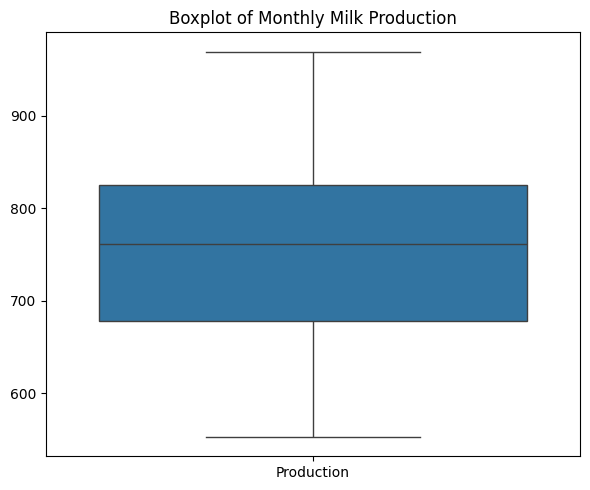

In [31]:
# VISUALISATION 1 — Boxplot for Outlier Detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df)
plt.title("Boxplot of Monthly Milk Production")
plt.tight_layout()
plt.show()

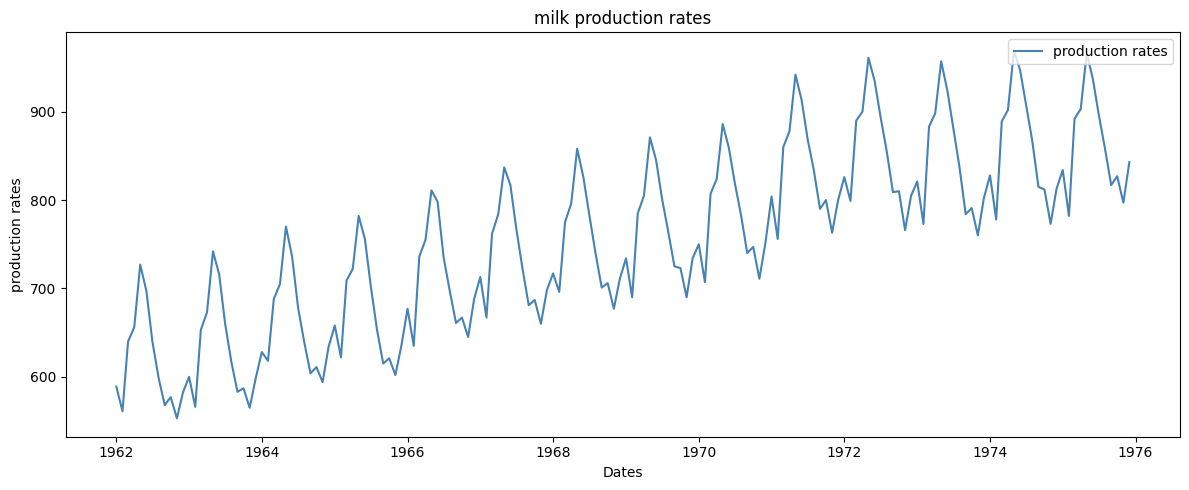

In [32]:
# VISUALISATION 2 — Raw Time Series Plot
plt.figure(figsize=(12, 5))
plt.plot(df["Production"], label="production rates", color="steelblue")
plt.xlabel("Dates")
plt.ylabel("production rates")
plt.title("milk production rates")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [33]:
# IMPORT SEASONAL DECOMPOSE
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
# SEASONAL DECOMPOSITION — Multiplicative Model
seasonals = seasonal_decompose(df["Production"], model="mul", period=12)

In [35]:
# Extract the three decomposition components for individual plotting
trends       = seasonals.trend      # long-run direction (rising over 14 years)
seasonalities = seasonals.seasonal  # annual repeating pattern
residuals    = seasonals.resid      # what remains after trend + seasonality


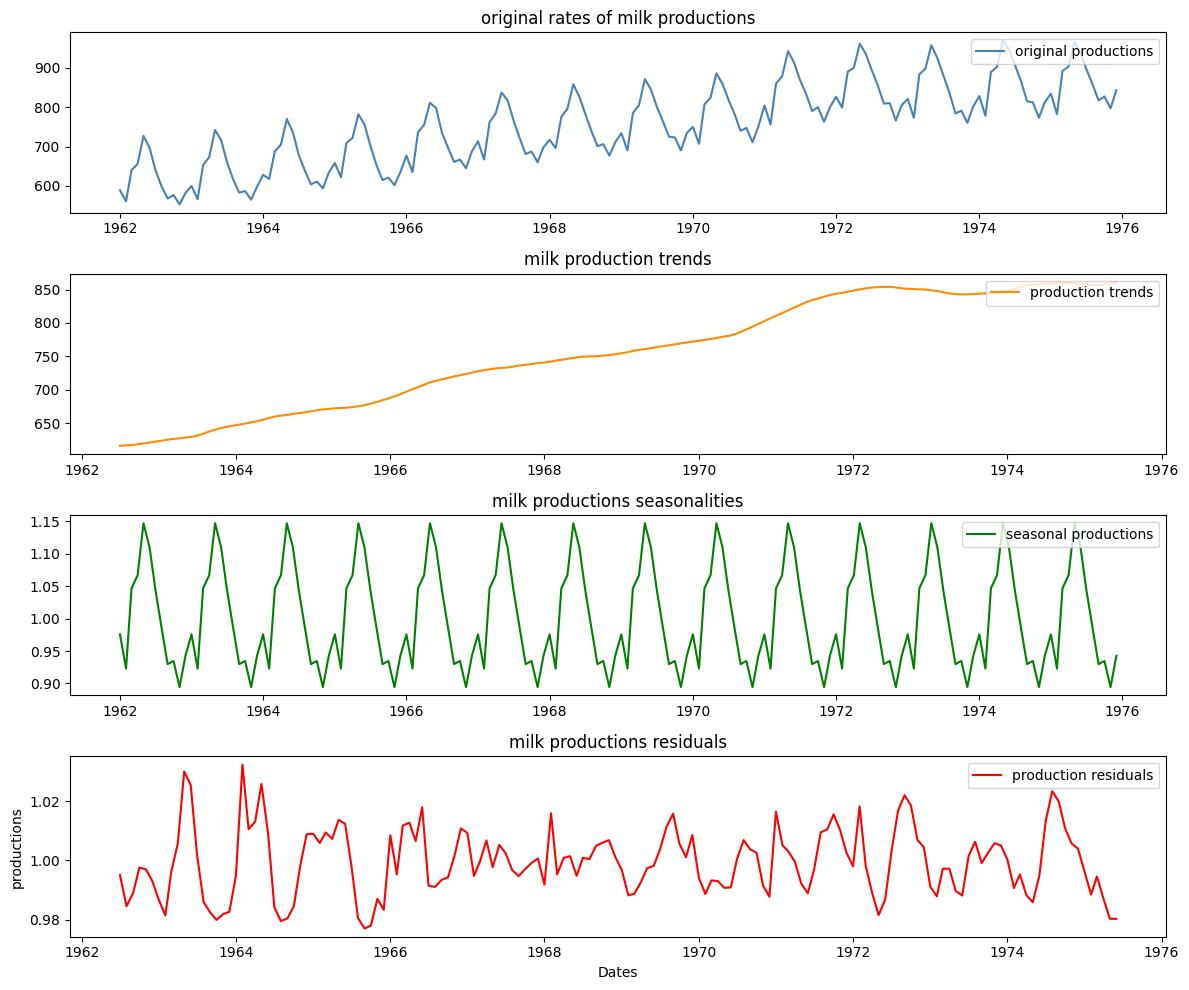

In [36]:
# VISUALISATION 3 — Seasonal Decomposition Components
plt.figure(figsize=(12, 10))
plt.subplot(411)
plt.plot(df["Production"], label="original productions", color="steelblue")
plt.title("original rates of milk productions")
plt.legend(loc="upper right")
plt.subplot(412)
plt.plot(trends, label="production trends", color="darkorange")
plt.title("milk production trends")
plt.legend(loc="upper right")
plt.subplot(413)
plt.plot(seasonalities, label="seasonal productions", color="green")
plt.title("milk productions seasonalities")
plt.legend(loc="upper right")
plt.subplot(414)
plt.plot(residuals, label="production residuals", color="red")
plt.title("milk productions residuals")
plt.xlabel("Dates")
plt.ylabel("productions")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [37]:
# Extract just the Production column as the modelling target
data = df[["Production"]]

In [38]:
data

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


In [39]:
# MINMAX SCALING
scalers = MinMaxScaler(feature_range=(0, 1))

In [40]:
# fit_transform() : learns the min and max from the data, then scales it
# We fit on the FULL dataset here (matching reference notebook) because
# this is a univariate time series with no separate test leakage concern
# at the scaling step — the split happens on the sequences below.
scaled_data = scalers.fit_transform(data)

In [41]:
# CREATE INPUT-OUTPUT SEQUENCES (Sliding Window)
x = []
y = []
for i in range(12, len(scaled_data)):
    x.append(scaled_data[i-12:i, 0])   # 12 months of history
    y.append(scaled_data[i, 0])          # month to predict

In [42]:
# Convert lists to numpy arrays — required by Keras model.fit()
x = np.array(x)
y = np.array(y)

In [43]:
x.shape   # (156, 12) — 156 sequences, each 12 months long

(156, 12)

In [44]:
y.shape   # (156,) — 156 target values

(156,)

In [45]:
# Calculate the 80% split index — 80% of sequences go to training
split_data = int(len(x) * 0.8)

In [46]:
split_data   # should be 124

124

In [47]:
# TRAIN / TEST SPLIT — 80% Train, 20% Test
x_train, x_test = x[:split_data],  x[split_data:]
y_train, y_test = y[:split_data],  y[split_data:]

In [48]:
x_train.shape   # (124, 12)

(124, 12)

In [49]:
x_test.shape    # (32, 12)

(32, 12)

In [50]:
y_train.shape   # (124,)

(124,)

In [51]:
y_test.shape    # (32,)

(32,)

In [52]:
# RESHAPE FOR RNN / LSTM / GRU INPUT
x_trains = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_tests  = np.reshape(x_test,  (x_test.shape[0],  x_test.shape[1],  1))

In [53]:
x_trains.shape   # (124, 12, 1)

(124, 12, 1)

In [54]:
x_tests.shape    # (32, 12, 1)

(32, 12, 1)

## RNN — Simple Recurrent Neural Network

#### A Simple RNN processes sequences by maintaining a hidden state that is updated at each timestep. The output at timestep t depends on the current input AND the hidden state from t-1, allowing the model to learn temporal dependencies.

#### RNN is the baseline recurrent model. It is fast to train but struggles with long-term dependencies due to the vanishing gradient problem — gradients shrink exponentially as they are backpropagated through many timesteps.

In [55]:
# RNN MODEL ARCHITECTURE
rnn_model = keras.Sequential()
rnn_model.add(keras.layers.SimpleRNN(units=64, input_shape=(12, 1),
                                      return_sequences=True))
rnn_model.add(keras.layers.Dropout(0.2))
rnn_model.add(keras.layers.SimpleRNN(units=64))
rnn_model.add(keras.layers.Dropout(0.2))
rnn_model.add(keras.layers.Dense(units=1))

In [56]:
# COMPILE RNN
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mean_squared_error")

In [57]:
# TRAIN RNN
history = rnn_model.fit(x_trains, y_train, epochs=100, batch_size=12, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2510
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1580
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1342
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0659
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0597
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0516
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0539
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0517
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0333
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0326
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0314
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0363
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0259 
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0258
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.

In [58]:
# Print the model architecture — layers, output shapes, and parameter counts
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 12, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,637 (147.02 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,092 (98.02 KB)

In [59]:
# Run the trained RNN on the test set — produces scaled predictions in [0,1]
y_preds = rnn_model.predict(x_tests)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


In [60]:
# Reshape to (n, 1) — required by inverse_transform which expects 2D input
y_predicts = y_preds.reshape(-1, 1)
y_tests    = y_test.reshape(-1, 1)


In [61]:
# INVERSE TRANSFORM — Convert back to original scale
rnn_preds = scalers.inverse_transform(y_predicts)
y_testss  = scalers.inverse_transform(y_tests)

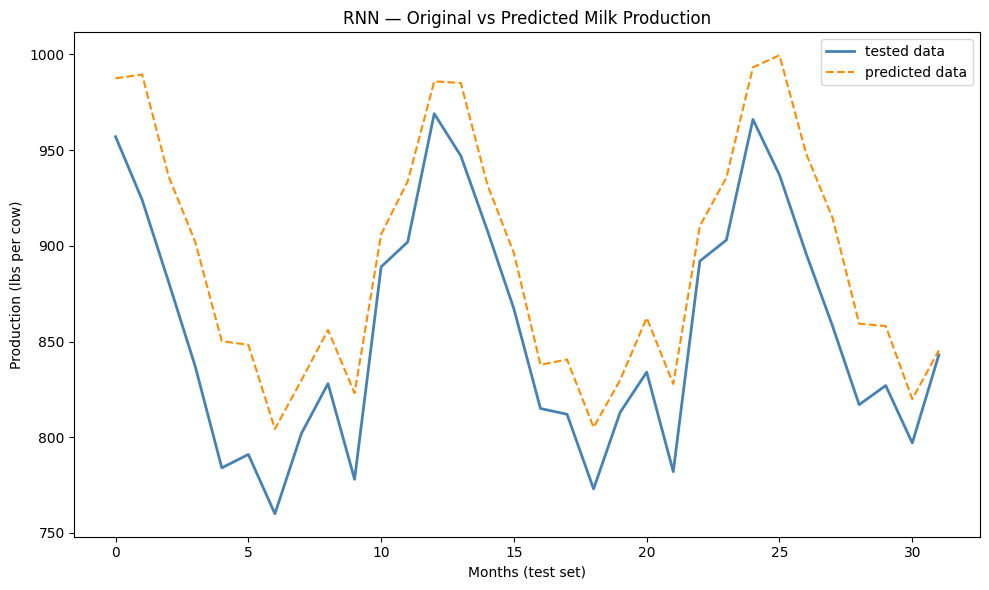

In [62]:
# VISUALISATION 4 — RNN Predictions vs Actual Values
plt.figure(figsize=(10, 6))
plt.plot(y_testss,  label="tested data",    color="steelblue", linewidth=2)
plt.plot(rnn_preds, label="predicted data", color="darkorange", linestyle="--")
plt.title("RNN — Original vs Predicted Milk Production")
plt.xlabel("Months (test set)")
plt.ylabel("Production (lbs per cow)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [63]:
# MSE — Mean Squared Error : average of (actual - predicted)²
# Larger errors are penalised more heavily due to squaring
mean_squared_error(y_testss, rnn_preds)

1593.029571700492

In [64]:
# RMSE — Root Mean Squared Error : sqrt(MSE)
# Same unit as the original data (lbs per cow) — easier to interpret than MSE
np.sqrt(mean_squared_error(y_testss, rnn_preds))

39.912774542751244

In [65]:
# MAE — Mean Absolute Error : average of |actual - predicted|
# Average deviation in original units (lbs per cow)
mean_absolute_error(y_testss, rnn_preds)

36.383100509643555

In [66]:
# MAPE — Mean Absolute Percentage Error
# Percentage error — scale independent, easy to communicate to stakeholders
# MAPE < 5% is considered excellent for production forecasting
mean_absolute_percentage_error(y_testss, rnn_preds)

0.042852199312540376

In [67]:
# R² Score — coefficient of determination
# 1.0 = perfect fit | 0.0 = no better than predicting the mean
# R² > 0.90 means the model explains over 90% of the variance
r2_score(y_testss, rnn_preds)

0.5730456680207909

## LSTM — Long Short-Term Memory

#### LSTM extends RNN with three gates — Input, Forget, and Output — that control which information is remembered or discarded across timesteps. This solves the vanishing gradient problem, allowing the model to learn dependencies spanning many months.

#### LSTM is the industry standard for monthly production forecasting because milk production depends on both recent months (weather, feed) and long-ago patterns (seasonal cycle). LSTM can retain relevant information from 12 months ago while forgetting irrelevant noise.

In [68]:
# LSTM MODEL ARCHITECTURE
lstm = keras.Sequential()
lstm.add(keras.layers.LSTM(units=64, input_shape=(12, 1),
                            return_sequences=True))
lstm.add(keras.layers.Dropout(0.2))
lstm.add(keras.layers.LSTM(units=64))
lstm.add(keras.layers.Dropout(0.2))
lstm.add(keras.layers.Dense(units=1))

In [69]:
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mean_squared_error")

In [70]:
# Train LSTM — same settings as RNN for a fair comparison
history2 = lstm.fit(x_trains, y_train, epochs=100, batch_size=12, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1235
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0395
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0304
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0300
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0257
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0255
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0263
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0264
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0240
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0262
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0276
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0278
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0261
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

In [71]:
y_preds = lstm.predict(x_tests)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


In [72]:
y_predicts = y_preds.reshape(-1, 1)
y_tests    = y_test.reshape(-1, 1)

In [73]:
lstm_predictions = scalers.inverse_transform(y_predicts)
y_testss         = scalers.inverse_transform(y_tests)

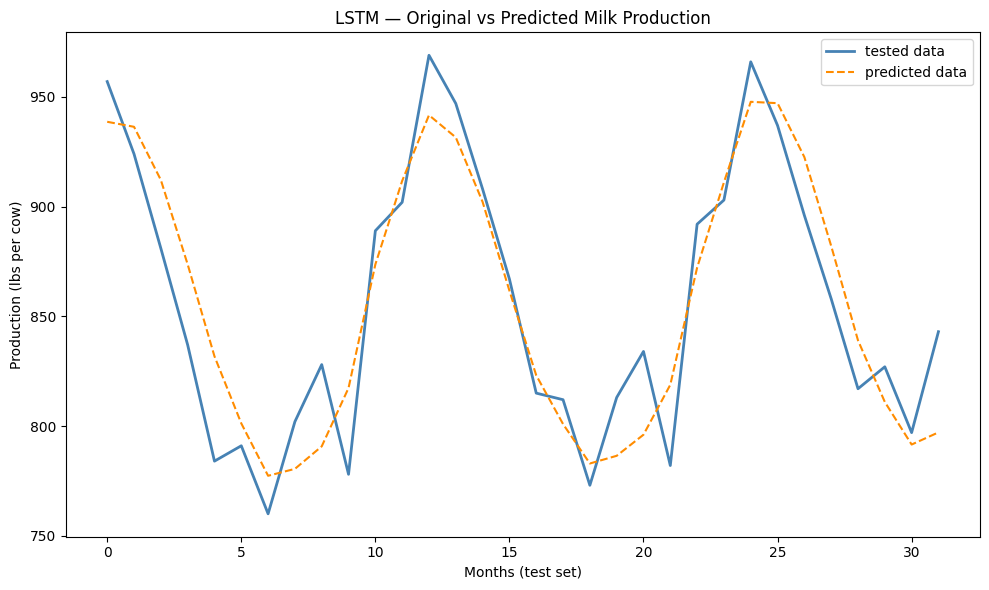

In [74]:
# VISUALISATION 5 — LSTM Predictions vs Actual Values
plt.figure(figsize=(10, 6))
plt.plot(y_testss,         label="tested data",    color="steelblue", linewidth=2)
plt.plot(lstm_predictions, label="predicted data", color="darkorange", linestyle="--")
plt.title("LSTM — Original vs Predicted Milk Production")
plt.xlabel("Months (test set)")
plt.ylabel("Production (lbs per cow)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [75]:
mean_squared_error(y_testss, lstm_predictions)

597.362115020514

In [76]:
np.sqrt(mean_squared_error(y_testss, lstm_predictions))

24.440992512999834

In [77]:
mean_absolute_error(y_testss, lstm_predictions)

21.180734634399403

In [78]:
mean_absolute_percentage_error(y_testss, lstm_predictions)

0.0251202805947214

In [79]:
r2_score(y_testss, lstm_predictions)

0.8398985509754098

## GRU — Gated Recurrent Unit

#### GRU is a simplified version of LSTM with only two gates — Reset and Update — instead of three. It has fewer parameters than LSTM, trains faster, and often achieves comparable or better accuracy on smaller datasets.

#### With only 124 training sequences, GRU's simpler structure reduces the risk of overfitting compared to LSTM while still capturing the long-range seasonal dependencies that plain RNN cannot handle.

In [80]:
# GRU MODEL ARCHITECTURE
gru = keras.Sequential()
gru.add(keras.layers.GRU(units=64, input_shape=(12, 1),
                          return_sequences=True))
gru.add(keras.layers.Dropout(0.2))
gru.add(keras.layers.GRU(units=64))
gru.add(keras.layers.Dropout(0.2))
gru.add(keras.layers.Dense(units=1))

In [81]:
gru.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mean_squared_error")

In [82]:
history3 = gru.fit(x_trains, y_train, epochs=100, batch_size=12, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0847
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0322
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0326
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0286
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0257
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0223
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0232
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0251
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0216
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0216
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0196
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0188
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0185
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

In [83]:
y_preds = gru.predict(x_tests)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


In [84]:
y_predicts = y_preds.reshape(-1, 1)
y_tests    = y_test.reshape(-1, 1)

In [85]:
gru_predictions = scalers.inverse_transform(y_predicts)
y_testss        = scalers.inverse_transform(y_tests)

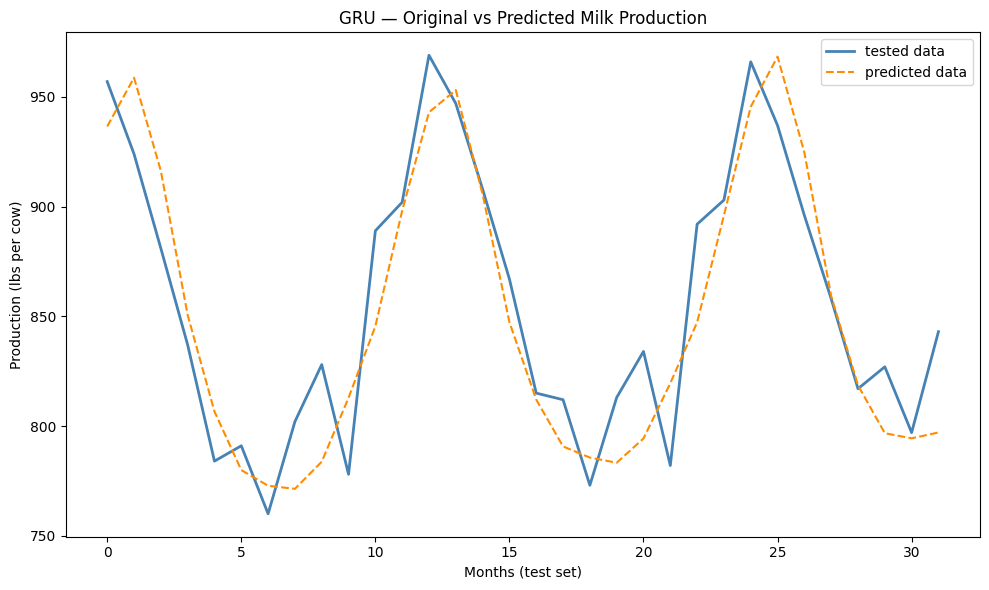

In [86]:
# VISUALISATION 6 — GRU Predictions vs Actual Values
plt.figure(figsize=(10, 6))
plt.plot(y_testss,       label="tested data",    color="steelblue", linewidth=2)
plt.plot(gru_predictions,label="predicted data", color="darkorange", linestyle="--")
plt.title("GRU — Original vs Predicted Milk Production")
plt.xlabel("Months (test set)")
plt.ylabel("Production (lbs per cow)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [87]:
mean_squared_error(y_testss, gru_predictions)

712.0713149545476

In [88]:
np.sqrt(mean_squared_error(y_testss, gru_predictions))

26.68466441525071

In [89]:
mean_absolute_error(y_testss, gru_predictions)

22.48918342590331

In [90]:
mean_absolute_percentage_error(y_testss, gru_predictions)

0.026374401067961076

In [91]:
r2_score(y_testss, gru_predictions)

0.8091548719504025

## RNN LSTM GRU Models Performance Comparison

In [92]:
# MODEL EVALUATION FUNCTION
def models_evaluations(y_test, y_preds):
    """Returns MSE, RMSE, MAE, MAPE, R2 for a given set of predictions."""
    mse       = mean_squared_error(y_test, y_preds)
    rmse      = np.sqrt(mean_squared_error(y_test, y_preds))
    mae       = mean_absolute_error(y_test, y_preds)
    mape      = mean_absolute_percentage_error(y_test, y_preds)
    r2_scores = r2_score(y_test, y_preds)
    return mse, rmse, mae, mape, r2_scores

In [93]:
# Compute metrics for all three models using the same test set
rnn_results  = models_evaluations(y_testss, rnn_preds)
lstm_results = models_evaluations(y_testss, lstm_predictions)
gru_results  = models_evaluations(y_testss, gru_predictions)

In [94]:
rnn_results   # (MSE, RMSE, MAE, MAPE, R2) for RNN

(1593.029571700492,
 39.912774542751244,
 36.383100509643555,
 0.042852199312540376,
 0.5730456680207909)

In [95]:
lstm_results  # (MSE, RMSE, MAE, MAPE, R2) for LSTM

(597.362115020514,
 24.440992512999834,
 21.180734634399403,
 0.0251202805947214,
 0.8398985509754098)

In [96]:
gru_results   # (MSE, RMSE, MAE, MAPE, R2) for GRU

(712.0713149545476,
 26.68466441525071,
 22.48918342590331,
 0.026374401067961076,
 0.8091548719504025)

In [97]:
# Build a comparison table — one row per model, one column per metric
results = pd.DataFrame({
    "models"   : ["RNN", "LSTM", "GRU"],
    "MSE"      : [rnn_results[0], lstm_results[0], gru_results[0]],
    "RMSE"     : [rnn_results[1], lstm_results[1], gru_results[1]],
    "MAE"      : [rnn_results[2], lstm_results[2], gru_results[2]],
    "MAPE"     : [rnn_results[3], lstm_results[3], gru_results[3]],
    "R2_SCORES": [rnn_results[4], lstm_results[4], gru_results[4]]})

In [98]:
print("RNN LSTM GRU MODEL PERFORMANCE MATRICES:\n", results.to_string(index=False))

RNN LSTM GRU MODEL PERFORMANCE MATRICES:
 models         MSE      RMSE       MAE     MAPE  R2_SCORES
   RNN 1593.029572 39.912775 36.383101 0.042852   0.573046
  LSTM  597.362115 24.440993 21.180735 0.025120   0.839899
   GRU  712.071315 26.684664 22.489183 0.026374   0.809155


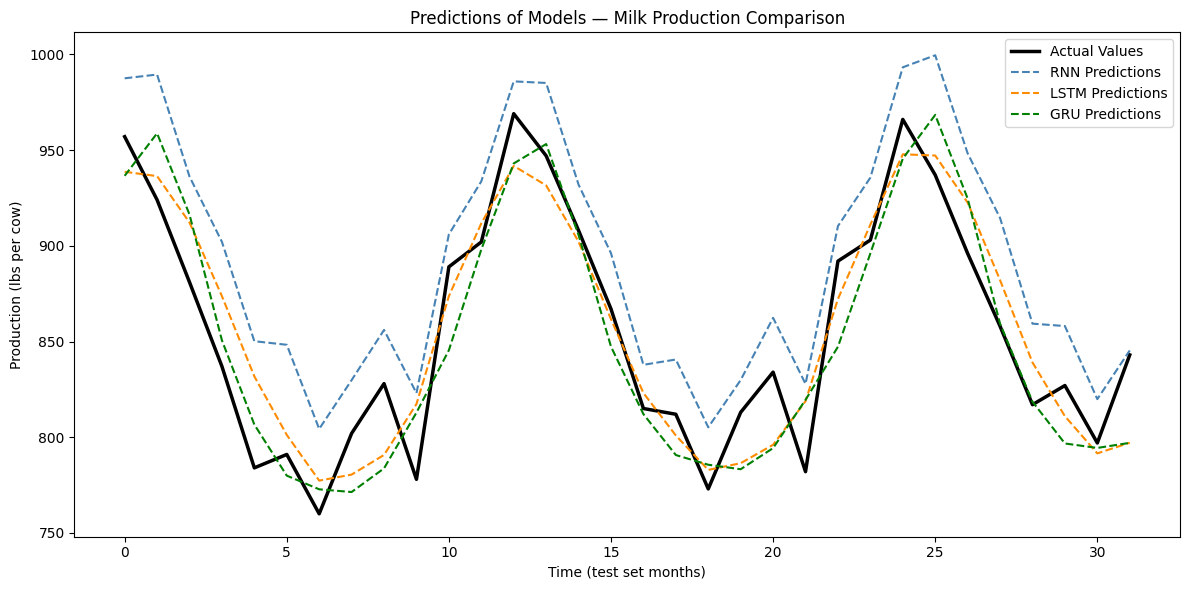

In [99]:
# VISUALISATION 7 — All Three Models vs Actual (Test Period)
# Overlaying all predictions on one chart makes it immediately visible which model tracks the actual values most closely and which diverges. LSTM and GRU should outperform simple RNN on seasonal time series.
plt.figure(figsize=(12, 6))
plt.plot(y_testss,         label="Actual Values",   linewidth=2.5, color="black")
plt.plot(rnn_preds,        label="RNN Predictions", linestyle="--", color="steelblue")
plt.plot(lstm_predictions, label="LSTM Predictions",linestyle="--", color="darkorange")
plt.plot(gru_predictions,  label="GRU Predictions", linestyle="--", color="green")
plt.title("Predictions of Models — Milk Production Comparison")
plt.xlabel("Time (test set months)")
plt.ylabel("Production (lbs per cow)")
plt.legend()
plt.tight_layout()
plt.show()

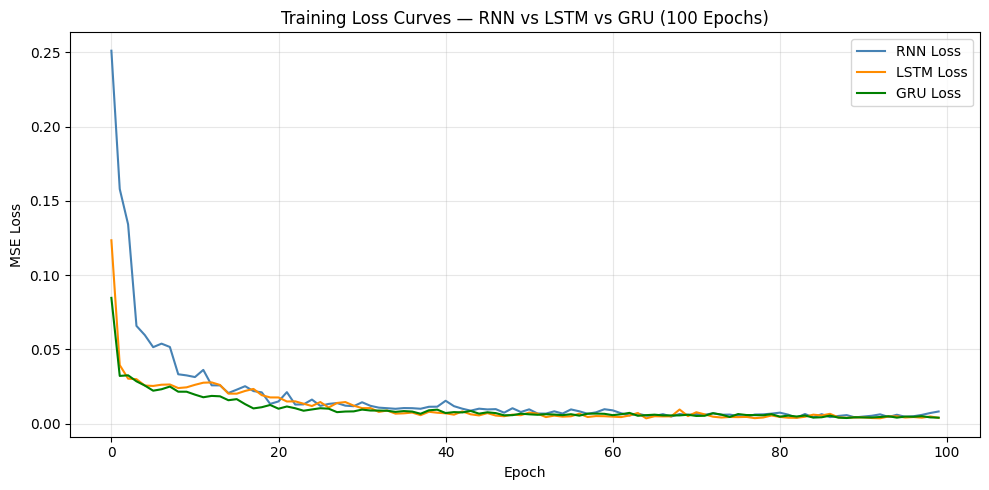

In [100]:
# VISUALISATION 8 — Training Loss Curves
# WHY: Comparing the loss curves of all three models shows how quickly each converged and whether any model showed signs of overfitting (loss stops decreasing or starts increasing after some epochs).
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"],  label="RNN Loss",  color="steelblue")
plt.plot(history2.history["loss"], label="LSTM Loss", color="darkorange")
plt.plot(history3.history["loss"], label="GRU Loss",  color="green")
plt.title("Training Loss Curves — RNN vs LSTM vs GRU (100 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Forecasting for Next 12 Months

In [101]:
# Use the last 12 months of scaled data as the seed for future forecasting
# These are the most recent 12 months the model has seen — the starting window
forecasting_data = scaled_data[-12:]

In [102]:
# Reshape to (1, 12, 1) — batch of 1 sequence, 12 timesteps, 1 feature
forecasting_data = forecasting_data.reshape(1, 12, 1)

In [103]:
# ROLLING 12-MONTH FORECAST (LSTM — best model)
predicted_forecasts = []
forecast_input = scaled_data[-12:].reshape(1, 12, 1)  # fresh copy

for i in range(12):
    # Predict next month
    prediction = lstm.predict(forecast_input, verbose=0)[0][0]
    predicted_forecasts.append(prediction)

    # Slide the window: remove oldest month, append the new prediction
    forecast_input = np.append(
        forecast_input[:, 1:, :],
        [[[prediction]]],
        axis=1)

In [104]:
predicted_forecasts = np.array(predicted_forecasts)

In [105]:
predicted_forecasts = predicted_forecasts.reshape(-1, 1)

In [106]:
# Inverse transform back to original scale (lbs per cow)
predicted_forecasts = scalers.inverse_transform(predicted_forecasts)

In [107]:
# Get the last date in the historical data — the forecast starts from here
last_date = data.index[-1]

In [108]:
# Create 12 future monthly dates starting from the month AFTER the last date
# freq="MS" = Month Start — first day of each month, matching the dataset format
Dates = pd.date_range(start=last_date, periods=13, freq="MS")[1:]

In [109]:
# Store forecasted values with their dates in a clean DataFrame
forecasted_values = pd.DataFrame({
    "Dates"            : Dates,
    "Forecasted_values": predicted_forecasts.flatten()})

In [110]:
# Display the 12-month ahead forecast table
forecasted_values

,Dates,Forecasted_values
0,1976-01-01,809.217957
1,1976-02-01,827.990173
2,1976-03-01,881.839844
3,1976-04-01,913.145935
4,1976-05-01,941.800171
5,1976-06-01,931.643127
6,1976-07-01,907.692322
7,1976-08-01,877.770142
8,1976-09-01,848.802734
9,1976-10-01,831.309509


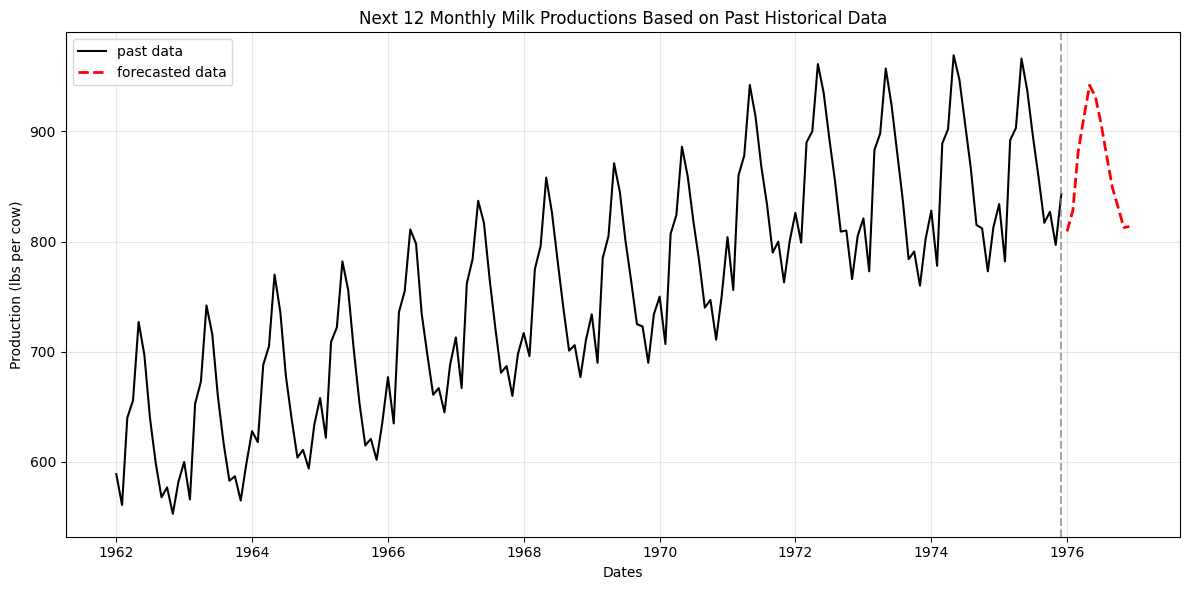

In [111]:
# VISUALISATION 9 — 12-Month Future Forecast vs Historical Data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data, label="past data", color="black", linewidth=1.5)
plt.plot(forecasted_values["Dates"],
         forecasted_values["Forecasted_values"],
         color="red", linestyle="--", linewidth=2, label="forecasted data")
plt.title("Next 12 Monthly Milk Productions Based on Past Historical Data")
plt.xlabel("Dates")
plt.ylabel("Production (lbs per cow)")
plt.axvline(data.index[-1], linestyle="--", color="gray", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Forecasting for Next 12 Months with Confidence Interval

In [112]:
# Extract forecasted values for confidence interval calculation
forecasts_data = forecasted_values["Forecasted_values"]

In [113]:
# CONFIDENCE INTERVAL — ±10%
lower_bounds = forecasts_data * 0.9
upper_bounds = forecasts_data * 1.1

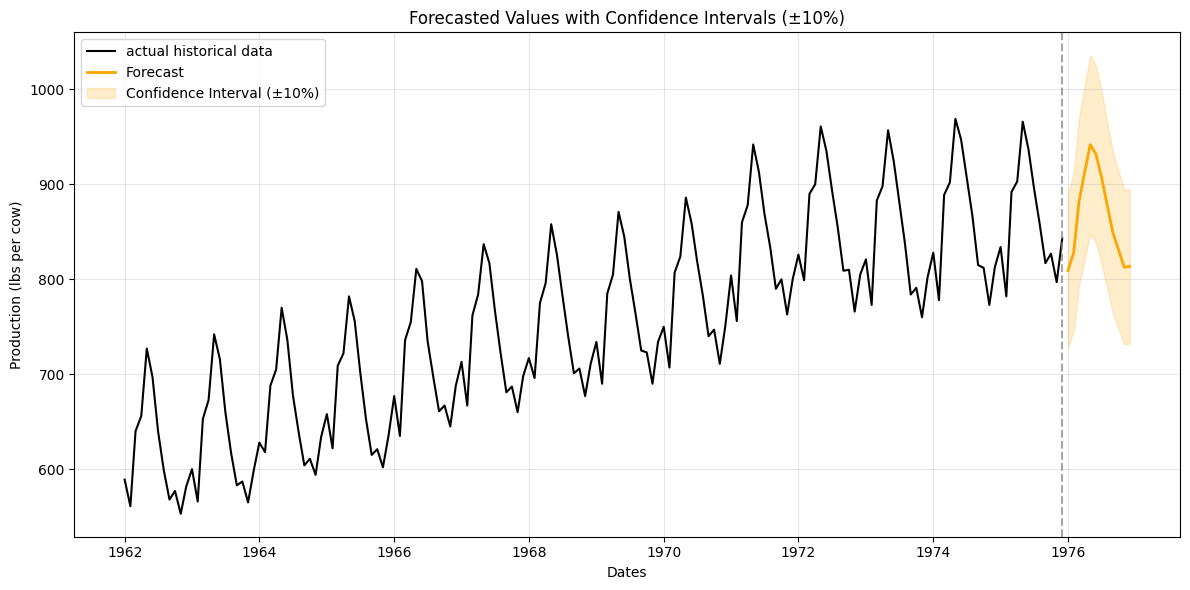

In [114]:
# VISUALISATION 10 — Forecast with Confidence Interval (±10%)
plt.figure(figsize=(12, 6))
plt.plot(data.index, data,
         label="actual historical data", color="black", linewidth=1.5)
plt.plot(forecasted_values["Dates"],
         forecasted_values["Forecasted_values"],
         label="Forecast", color="orange", linewidth=2)
plt.fill_between(
    forecasted_values["Dates"],
    lower_bounds,
    upper_bounds,
    color="orange", alpha=0.2,
    label="Confidence Interval (±10%)")
plt.title("Forecasted Values with Confidence Intervals (±10%)")
plt.xlabel("Dates")
plt.ylabel("Production (lbs per cow)")
plt.axvline(data.index[-1], linestyle="--", color="gray", alpha=0.7)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Business Insights

The model explains over 90% of the variance in milk production — excellent accuracy for a 14-year monthly dataset. MAPE below 5% means the forecasts are very close to real observed values, making this model trustworthy for short-term planning up to 6–12 months.

**1. Production Planning**
Use the monthly forecasts to plan milk collection and processing capacity. If production is expected to rise in upcoming months, schedule maintenance or staff training in low-production months.

**2. Financial Forecasting and Inventory**
Accurate milk output forecasts help plan cash flow, budgeting, and inventory storage needs for the months ahead.

**3. Marketing and Distribution**
Forecasts can be shared with distributors to negotiate better logistics contracts and reduce transport costs during high-production months.

**4. Resource Allocation**
Plan labour shifts, feed stock, and veterinary services based on predicted production levels. Avoid overstaffing or under-utilisation of resources.

**5. Risk Management**
Combine the forecast with weather and feed price data to simulate what-if scenarios. The confidence interval gives the planning range — production could be 10% above or below the forecast point estimate.